# How often would an error band set off a false alarm?

Stage 1 of this project (the notebooks in `notebooks/`) compared glucose forecasters. This notebook takes one of them, the **GLIMMER fixed-weight model** (a CNN-LSTM trained to care more about dangerous highs and lows), and asks a practical question about its 60-minute-ahead predictions:

> Suppose we put an error band around every prediction, and raised an alarm whenever **either edge of the band went past the danger zone**: the bottom edge under 70 mg/dL, or the top edge over 180 mg/dL. How often would that alarm go off for no reason?

Some terms, so the numbers below are unambiguous:

- **Danger** means the real glucose was under 70 or over 180 mg/dL. **Safe** means it was between 70 and 180.
- A **trigger** is an alarm: the band's bottom edge is under 70, or its top edge is over 180.
- A **false trigger** is a trigger when the real glucose was actually safe.
- The headline number is the **false trigger rate**: of all the readings where real glucose was safe, the share that set off the alarm.
- The other side of the trade is **danger caught**: of all the readings where real glucose really was dangerous, the share that set off the alarm.

A band that is wide will trigger more, catching more real danger but also falsely triggering more. So the question is not a single number but a trade-off, and comparing methods fairly means comparing them at the same false trigger rate.

Three ways of building the band are compared, each borrowed from a different field:

- **Conformal (basic).** Look at how wrong the model was on data it was not trained on, find the error size that covers the chosen share of cases, and use that as a fixed plus-or-minus around every prediction. It works for any model and is the simplest, so it is the reference point.
- **GARCH (finance).** Built to track volatility. It widens the band when the model's recent errors have been large and narrows it when they have been small. A 60-minute forecast's error is only known 60 minutes later, so it can only learn from errors that have already played out.
- **Analog Ensemble (weather).** Find the 50 past moments that looked most like right now (similar last two hours of glucose, insulin, and carbs, at a similar time of day), look at how wrong the model was in each, and add that spread of errors to today's prediction. The band can lean to one side.

Each method is fitted only on a patient's **validation period** (data the model did not train on, from before the test period) and judged on the **test period**, which nothing was fitted on. Nothing is retrained. All 25 AZT1D patients are used.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from azt1d import loading, plotting
from azt1d import reference as ref
from azt1d.glimmer import checkpoint as ckpt
from azt1d.glimmer import uncertainty as unc
from azt1d.glimmer.clinical import clarke_error_grid_zones, clarke_zone_percentages, draw_clarke_grid

plotting.apply_style()
pd.set_option("display.max_columns", None)

METHODS = unc.METHODS
METHOD_COLOR = dict(zip(METHODS, plotting.CATEGORICAL[:3]))
CKPT_DIR = PROJECT_ROOT / "data" / "processed" / "checkpoints" / "cnn_lstm_v1"
TARGETS = (0.35, 0.50)  # false trigger rates to compare the methods at (see the note in section 4 on why not lower)

## 1. Rebuild the forecasts and check the setup

The checkpoints only saved each patient's test predictions, and the methods need validation-period predictions too, so both are rebuilt from the saved model weights. Then a few checks on things that would quietly ruin the comparison if they were wrong.

In [2]:
df = loading.load_real_dataset(PROJECT_ROOT / "data" / "raw", PROJECT_ROOT / "data" / "processed")
subject_ids = sorted(int(s) for s in df["subject_id"].unique())

frames, results, gaps = {}, {}, {}
for sid in subject_ids:
    res = ckpt.load_result(CKPT_DIR, sid)
    df_subject = df[df["subject_id"] == sid].reset_index(drop=True)
    val, test = unc.forecast_frames(res, df_subject)
    frames[sid], results[sid] = (val, test), res
    gaps[sid] = unc.matches_stored_predictions(test, res)

print(f"Rebuilt forecasts for {len(frames)} patients.")
print(f"Largest gap between rebuilt and originally saved test predictions: {max(gaps.values()):.6f} mg/dL")
print(f"Validation windows per patient: {min(len(f[0].pred) for f in frames.values())} to {max(len(f[0].pred) for f in frames.values())}")
print(f"Test windows per patient:       {min(len(f[1].pred) for f in frames.values())} to {max(len(f[1].pred) for f in frames.values())}")

Rebuilt forecasts for 25 patients.
Largest gap between rebuilt and originally saved test predictions: 0.000000 mg/dL
Validation windows per patient: 1281 to 2198
Test windows per patient:       1601 to 2747


In [3]:
# 1. Rebuilt predictions match what was saved at training time.
assert max(gaps.values()) < 0.05, "rebuilt predictions do not match the checkpoints"

# 2. GARCH never peeks. Changing residuals that had not happened yet (target time after the
#    moment the forecast was issued) must not change the variance used for that forecast.
val1, test1 = frames[1]
params = unc.fit_garch(val1.resid)
e = np.concatenate([val1.resid, test1.resid])[:300]
e_changed = e.copy()
e_changed[150:] += 1000.0
init_var = float(np.var(val1.resid - params.mu))  # from calibration data only
v_a = unc.garch_h_step_variance(e, params, init_var)
v_b = unc.garch_h_step_variance(e_changed, params, init_var)
lag = unc.LAG
assert np.allclose(v_a[lag:150 + lag], v_b[lag:150 + lag]), "GARCH variance changed because of a future residual"
assert not np.allclose(v_a[150 + lag:], v_b[150 + lag:]), "changed residuals should matter once they are actually known"

# 3. Conformal quantile matches a hand calculation: residual sizes 1..100, 90% band -> exactly 91.
assert unc.conformal_halfwidth(np.arange(1, 101, dtype=float), alpha=0.1) == 91.0

# 4. Calibration data always comes before the test period, and analogs are spread out.
for sid, (v, t) in frames.items():
    assert v.target_time.max() < t.target_time.min(), "calibration period overlaps the test period"
picked = unc.select_analogs(np.random.default_rng(0).random(1735), k=50, min_gap=12, pool_cap=600)
assert len(picked) == 50 and np.diff(np.sort(picked)).min() >= 12

# 5. The trigger arithmetic, on a hand-made example.
#    readings: real 50 (danger), 100 (safe), 100 (safe), 200 (danger)
#    triggers: low edge 60<70 fires, low edge 60<70 fires, nothing fires, high edge 250>180 fires
a = np.array([50.0, 100.0, 100.0, 200.0])
lo = np.array([60.0, 60.0, 90.0, 150.0])
hi = np.array([100.0, 200.0, 120.0, 250.0])
m = unc.trigger_metrics(a, lo, hi)
assert m["false_trigger_rate"] == 0.5 and m["danger_caught"] == 1.0
#    when both edges cross, the bigger overshoot wins (30 vs 20 -> low edge; 10 vs 120 -> high edge)
sw = unc.swapped_prediction(np.array([100.0, 100.0]), np.array([40.0, 60.0]), np.array([200.0, 300.0]))
assert list(sw) == [40.0, 300.0]

print("All checks passed.")

All checks passed.


## 2. Build the bands

Each patient gets one engine holding all three methods, so a band of any size can be produced quickly. The GARCH numbers below are a curiosity: alpha is how strongly one big error widens the next band, and beta is how long that widening lingers.

In [4]:
engines = {sid: unc.BandEngine(frames[sid][0], frames[sid][1]) for sid in subject_ids}
actuals = {sid: frames[sid][1].actual for sid in subject_ids}
actual_all = np.concatenate([actuals[s] for s in subject_ids])
pred_all = np.concatenate([frames[s][1].pred for s in subject_ids])


def pooled_bands(method, level):
    """One method's band at one size, all 25 patients' test periods joined end to end."""
    los, his = zip(*(engines[s].bands(method, level) for s in subject_ids))
    return np.concatenate(los), np.concatenate(his)


region_all = unc.region_of(actual_all)
print("Test readings by what real glucose was:", {r: int((region_all == r).sum()) for r in ("hypo", "normal", "hyper")})
garch_p = pd.DataFrame([{"alpha": e.garch_params.alpha, "beta": e.garch_params.beta} for e in engines.values()])
garch_p["alpha_plus_beta"] = garch_p.alpha + garch_p.beta
garch_p.describe().loc[["mean", "min", "max"]].round(3)

Test readings by what real glucose was: {'hypo': 963, 'normal': 47521, 'hyper': 11525}


,alpha,beta,alpha_plus_beta
mean,0.896,0.088,0.984
min,0.721,0.000,0.903
max,1.000,0.279,1.000


## 3. The rule, applied to ordinary 80% and 95% bands

First the obvious version: build the usual 80% and 95% bands and trigger whenever either edge leaves the safe zone. For comparison, the last row uses the model's point forecast alone as the alarm (no band: trigger when the forecast itself is under 70 or over 180).

"Share of alarms that were false" is a different way to look at the same thing: when an alarm goes off, how often is it wrong.

In [5]:
SWEEP = np.round(np.concatenate([np.arange(0.05, 0.5, 0.05), np.arange(0.5, 0.9901, 0.01)]), 2)

sweep_rows = []
for method in METHODS:
    for level in SWEEP:
        lo, hi = pooled_bands(method, level)
        sweep_rows.append({"method": method, "level": float(level), **unc.trigger_metrics(actual_all, lo, hi)})
sweep = pd.DataFrame(sweep_rows)

# Wider bands should only ever trigger more.
for method in METHODS:
    rates = sweep[sweep.method == method].sort_values("level")["false_trigger_rate"].to_numpy()
    assert (np.diff(rates) >= -1e-9).all(), f"{method}: false trigger rate fell as the band got wider"

point = unc.trigger_metrics(actual_all, pred_all, pred_all)
cols = {"false_trigger_rate": "false trigger rate (of safe readings)", "danger_caught": "danger caught",
        "lows_caught": "real lows caught", "highs_caught": "real highs caught", "share_of_alarms_false": "share of alarms that were false"}
rows = []
for method in METHODS:
    for level in (0.8, 0.95):
        r = sweep[(sweep.method == method) & np.isclose(sweep.level, level)].iloc[0]
        rows.append({"alarm source": method, "band": f"{int(level * 100)}%", **{cols[k]: r[k] for k in cols}})
rows.append({"alarm source": "Point forecast (no band)", "band": "-", **{cols[k]: point[k] for k in cols}})
pd.DataFrame(rows).set_index(["alarm source", "band"]).round(3)

false trigger rate (of safe readings)  \
alarm source             band                                          
Conformal                80%                                   0.864   
                         95%                                   1.000   
GARCH                    80%                                   0.799   
                         95%                                   0.941   
Analog Ensemble          80%                                   0.683   
                         95%                                   0.927   
Point forecast (no band) -                                     0.320   

                               danger caught  real lows caught  \
alarm source             band                                    
Conformal                80%           0.974             0.939   
                         95%           1.000             1.000   
GARCH                    80%           0.954             0.947   
                         95%           0.990             0.995   
Analog Ensemble          80%           0.923             0.802   
                         95%           0.991             0.966   
Point forecast (no band) -             0.722             0.454   

                               real highs caught  \
alarm source             band                      
Conformal                80%               0.977   
                         95%               1.000   
GARCH                    80%               0.954   
                         95%               0.990   
Analog Ensemble          80%               0.934   
                         95%               0.993   
Point forecast (no band) -                 0.744   

                               share of alarms that were false  
alarm source             band                                   
Conformal                80%                             0.771  
                         95%                             0.792  
GARCH                    80%                             0.761  
                         95%                             0.783  
Analog Ensemble          80%                             0.738  
                         95%                             0.781  
Point forecast (no band) -                               0.627

## 4. The trade-off, and a fair comparison

Wider bands catch more real danger and falsely trigger more, so the three methods cannot be compared at the same band size. The curves below plot, for every band size from 5% to 99%, how much real danger is caught against how often the alarm falsely triggers. A curve that sits higher for the same false trigger rate is a genuinely better alarm. The black dot is the point forecast used as an alarm on its own.

The three panels split "danger caught" into all danger, real lows only, and real highs only. The horizontal axis is always the overall false trigger rate. The dashed lines mark the two false trigger rates compared in the rest of the notebook (35% and 50%). They are not lower because, as the next table shows, no band can push a method below the false trigger rate of its own forecast line.

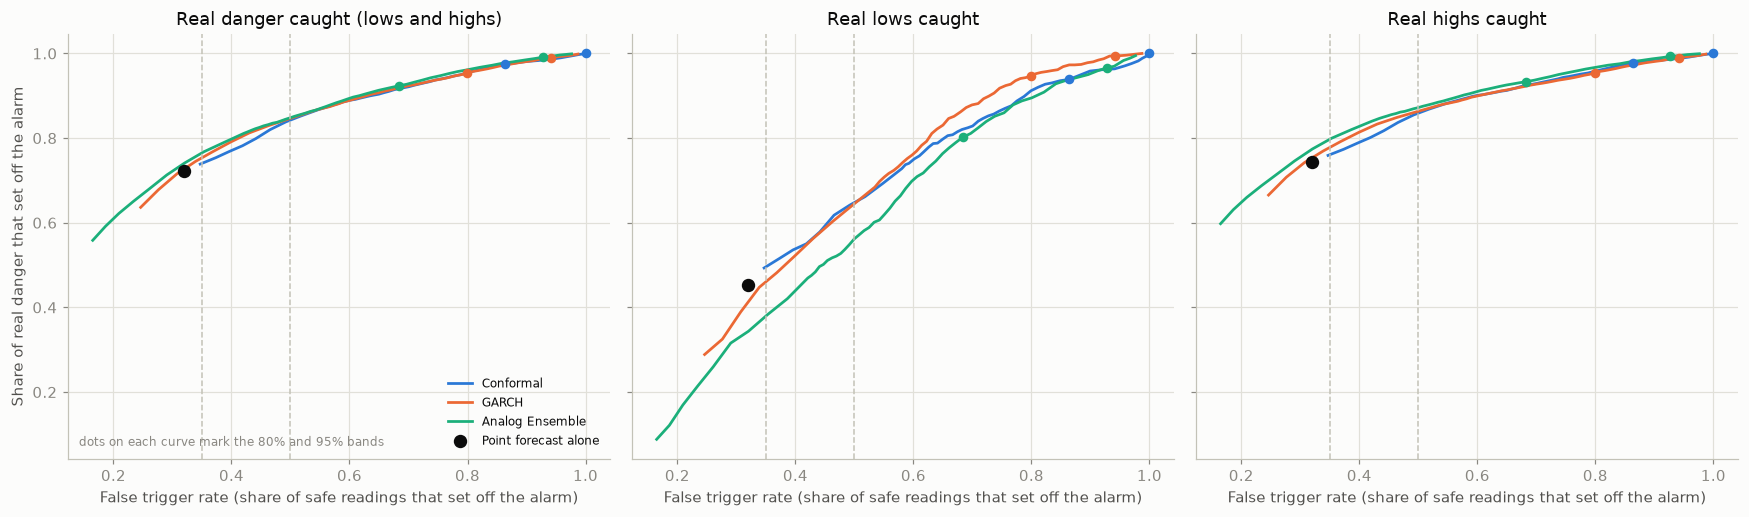

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)
panels = [("danger_caught", "Real danger caught (lows and highs)"), ("lows_caught", "Real lows caught"), ("highs_caught", "Real highs caught")]
for ax, (col, title) in zip(axes, panels):
    for method in METHODS:
        s = sweep[sweep.method == method].sort_values("level")
        ax.plot(s.false_trigger_rate, s[col], color=METHOD_COLOR[method], linewidth=1.8, label=method)
        for lv in (0.8, 0.95):
            r = s[np.isclose(s.level, lv)].iloc[0]
            ax.scatter([r.false_trigger_rate], [r[col]], color=METHOD_COLOR[method], s=28, zorder=3)
    ax.scatter([point["false_trigger_rate"]], [point[col]], color=plotting.INK_PRIMARY, s=60, zorder=4, label="Point forecast alone")
    for t in TARGETS:
        ax.axvline(t, linestyle="--", color=plotting.BASELINE, linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("False trigger rate (share of safe readings that set off the alarm)")
axes[0].set_ylabel("Share of real danger that set off the alarm")
axes[0].legend(frameon=False, fontsize=8, loc="lower right")
axes[0].annotate("dots on each curve mark the 80% and 95% bands", (0.02, 0.03), xycoords="axes fraction", fontsize=8, color=plotting.INK_MUTED)
fig.tight_layout()
plt.show()

**A floor on false triggers.** A band is centered on a forecast and only ever adds room on either side of it, so making a band wider can only add triggers, never remove them. That means every method has a lowest possible false trigger rate: the rate you get with a band of essentially zero width, where the alarm is just the method's own center line crossing 70 or 180. Conformal is centered on the raw model forecast, while GARCH and the analog ensemble also shift the center to correct for the model's typical bias, which is why their floors are lower.

In [7]:
floor_rows = [{"alarm source": "Point forecast (raw model)", "false trigger rate": point["false_trigger_rate"], "danger caught": point["danger_caught"]}]
for method in METHODS:
    lo, hi = pooled_bands(method, 0.001)  # a band of essentially zero width
    tm = unc.trigger_metrics(actual_all, lo, hi)
    floor_rows.append({"alarm source": f"{method}, zero-width band", "false trigger rate": tm["false_trigger_rate"], "danger caught": tm["danger_caught"]})
pd.DataFrame(floor_rows).set_index("alarm source").round(3)

,false trigger rate,danger caught
alarm source,,
Point forecast (raw model),0.320,0.722
"Conformal, zero-width band",0.320,0.722
"GARCH, zero-width band",0.221,0.609
"Analog Ensemble, zero-width band",0.144,0.527


Now the same comparison in numbers, at a matched false trigger rate. For each method, the band size is tuned until it falsely triggers on exactly 35% of safe readings (and again on 50%). Then everything else about the alarm is compared at that setting. "False via low edge" and "false via high edge" split the false triggers by which edge caused them.

In [8]:
matched = {(m, t): unc.level_for_false_trigger_rate(engines, actuals, m, t) for m in METHODS for t in TARGETS}

rows = []
for t in TARGETS:
    for method in METHODS:
        lvl = matched[(method, t)]
        lo, hi = pooled_bands(method, lvl)
        tm = unc.trigger_metrics(actual_all, lo, hi)
        assert abs(tm["false_trigger_rate"] - t) < 0.003, "matching missed its target"
        rows.append({
            "false trigger target": f"{int(t * 100)}%", "method": method, "band size needed": lvl,
            "false trigger rate": tm["false_trigger_rate"], "danger caught": tm["danger_caught"],
            "real lows caught": tm["lows_caught"], "real highs caught": tm["highs_caught"],
            "share of alarms that were false": tm["share_of_alarms_false"],
            "false via low edge": tm["false_via_low_edge"], "false via high edge": tm["false_via_high_edge"],
        })
matched_table = pd.DataFrame(rows).set_index(["false trigger target", "method"])
print("For reference, the point forecast alone falsely triggers on "
      f"{point['false_trigger_rate']:.1%} of safe readings and catches {point['danger_caught']:.1%} of real danger "
      f"({point['lows_caught']:.1%} of lows, {point['highs_caught']:.1%} of highs).")
matched_table.round(3)

For reference, the point forecast alone falsely triggers on 32.0% of safe readings and catches 72.2% of real danger (45.4% of lows, 74.4% of highs).


band size needed  false trigger rate  \
false trigger target method                                                  
35%                  Conformal                   0.055                0.35   
                     GARCH                       0.220                0.35   
                     Analog Ensemble             0.395                0.35   
50%                  Conformal                   0.364                0.50   
                     GARCH                       0.454                0.50   
                     Analog Ensemble             0.610                0.50   

                                      danger caught  real lows caught  \
false trigger target method                                             
35%                  Conformal                0.740             0.494   
                     GARCH                    0.755             0.457   
                     Analog Ensemble          0.765             0.376   
50%                  Conformal                0.842             0.647   
                     GARCH                    0.846             0.644   
                     Analog Ensemble          0.848             0.563   

                                      real highs caught  \
false trigger target method                               
35%                  Conformal                    0.761   
                     GARCH                        0.780   
                     Analog Ensemble              0.797   
50%                  Conformal                    0.859   
                     GARCH                        0.863   
                     Analog Ensemble              0.872   

                                      share of alarms that were false  \
false trigger target method                                             
35%                  Conformal                                  0.643   
                     GARCH                                      0.638   
                     Analog Ensemble                            0.635   
50%                  Conformal                                  0.693   
                     GARCH                                      0.692   
                     Analog Ensemble                            0.692   

                                      false via low edge  false via high edge  
false trigger target method                                                    
35%                  Conformal                     0.060                0.289  
                     GARCH                         0.087                0.263  
                     Analog Ensemble               0.055                0.295  
50%                  Conformal                     0.109                0.391  
                     GARCH                         0.147                0.355  
                     Analog Ensemble               0.109                0.391

## 5. Where the alarms fire

Each figure is a 24-hour stretch of one patient's held-out test data, centered on that patient's lowest real glucose reading. The black line is real glucose, the colored line is the prediction, and the shaded band is the method's band at the size that gives a 35% false trigger rate. The dashed lines mark 70 and 180 mg/dL. Along the bottom, each tick is a moment the alarm went off: the upper row of ticks are **correct** triggers (real glucose was in danger) and the lower row are **false** triggers (real glucose was safe).

Subject 1 is the project's usual example. The best and worst patients are picked automatically from the model's own test error.

Subjects shown: 1 (usual example), 16 (best, RMSE 33.1), 21 (worst, RMSE 54.9)


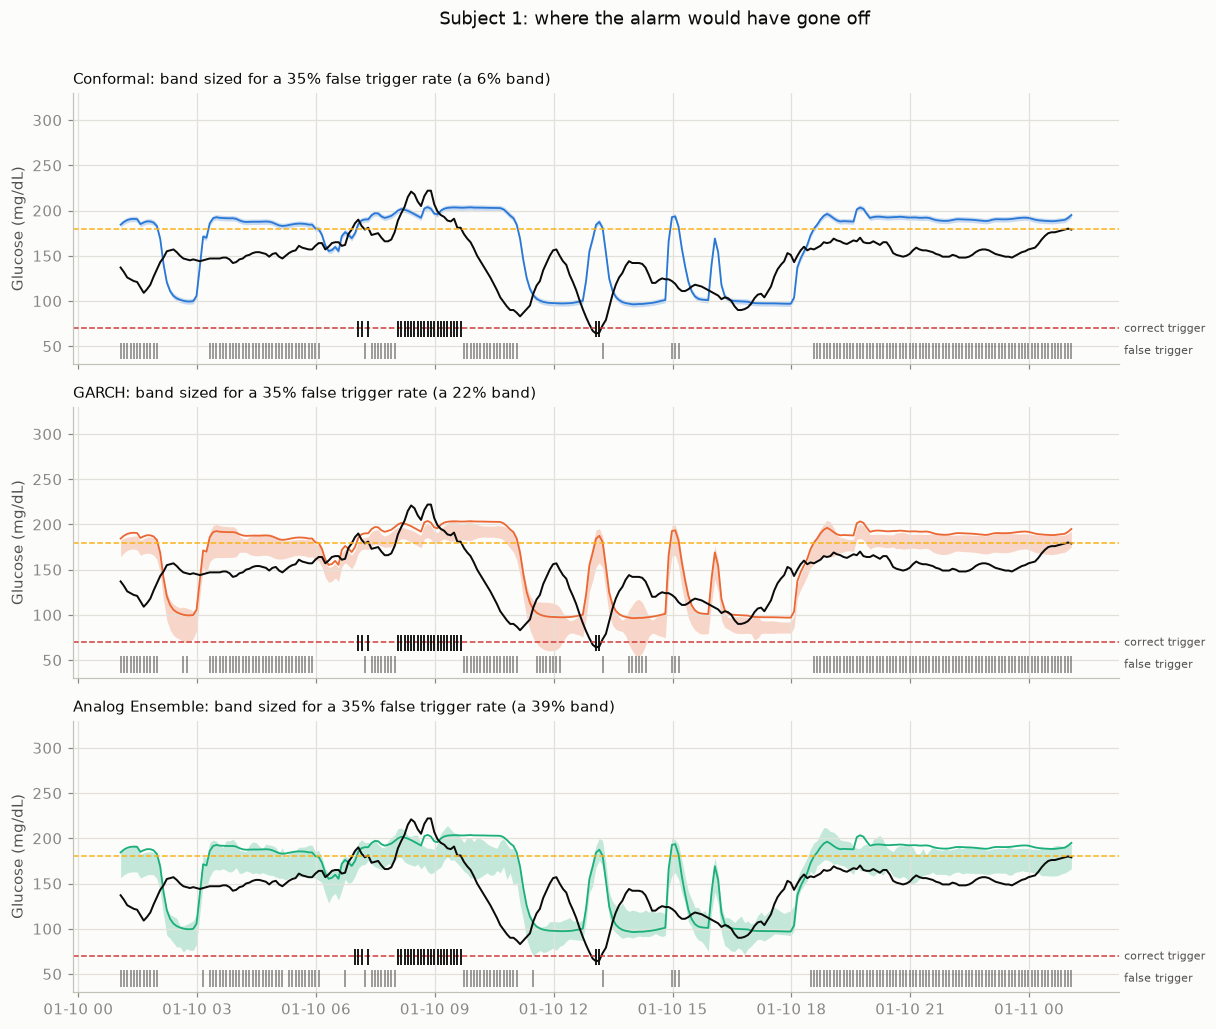

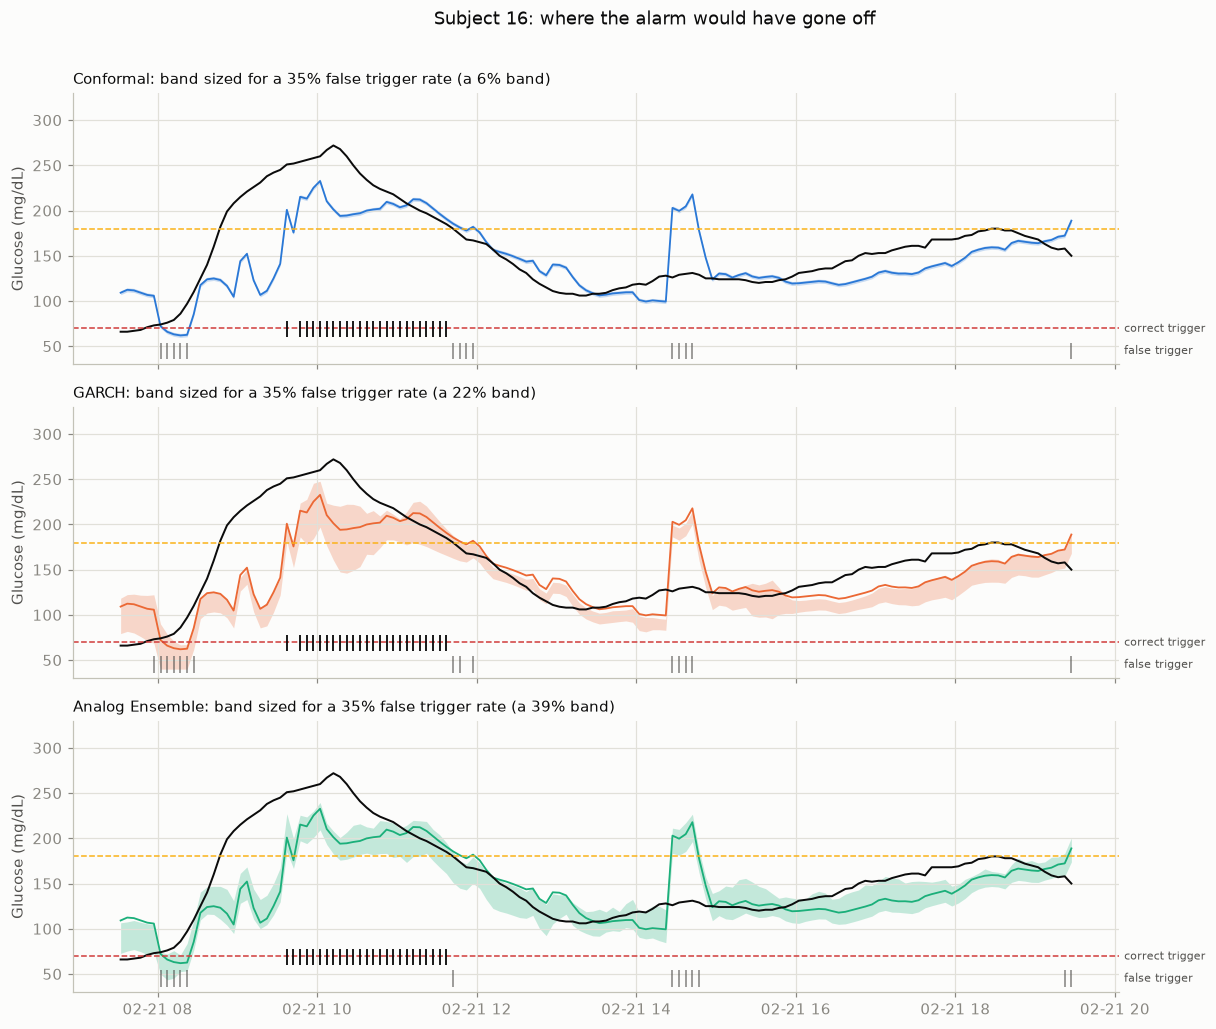

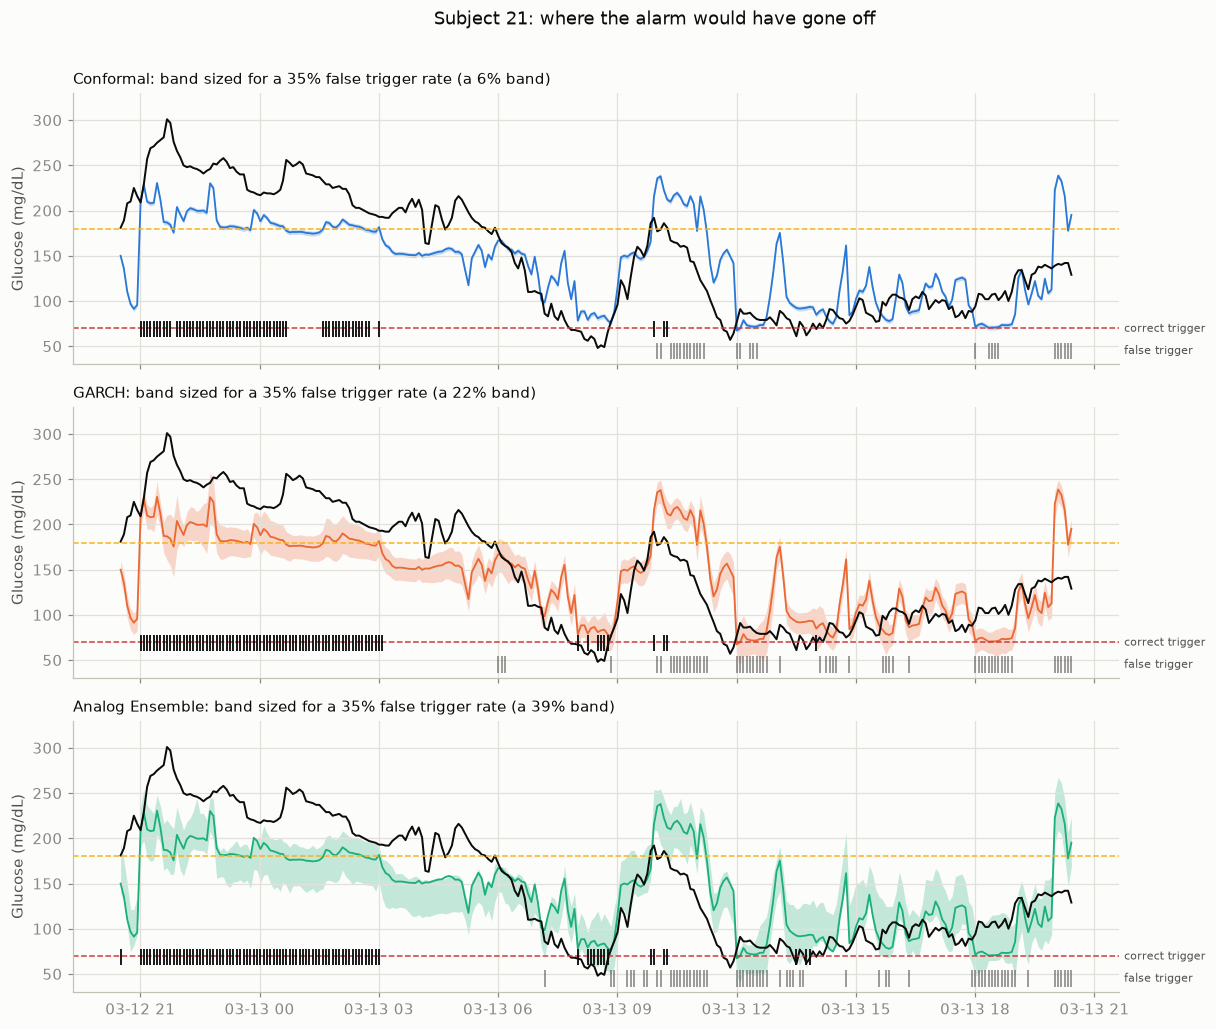

In [9]:
rmse = {sid: results[sid].rmse for sid in subject_ids}
best_sid, worst_sid = min(rmse, key=rmse.get), max(rmse, key=rmse.get)
show_sids = list(dict.fromkeys([1, best_sid, worst_sid]))
print(f"Subjects shown: 1 (usual example), {best_sid} (best, RMSE {rmse[best_sid]:.1f}), {worst_sid} (worst, RMSE {rmse[worst_sid]:.1f})")


def plot_triggers(sid, target=TARGETS[0], half_window=144):
    val, test = frames[sid]
    center = int(np.argmin(test.actual))
    a, b = max(0, center - half_window), min(len(test.pred), center + half_window)
    x = pd.to_datetime(test.target_time[a:b])
    danger = (test.actual < ref.HYPO_THRESHOLD) | (test.actual > ref.HYPER_THRESHOLD)
    fig, axes = plt.subplots(3, 1, figsize=(12, 9.5), sharex=True, sharey=True)
    for ax, method in zip(axes, METHODS):
        color = METHOD_COLOR[method]
        lo, hi = engines[sid].bands(method, matched[(method, target)])
        trig, _, _ = unc.trigger_flags(lo, hi)
        ax.fill_between(x, lo[a:b], hi[a:b], color=color, alpha=0.25, linewidth=0)
        ax.plot(x, test.pred[a:b], color=color, linewidth=1.2)
        ax.plot(x, test.actual[a:b], color=plotting.INK_PRIMARY, linewidth=1.3)
        ax.axhline(ref.HYPO_THRESHOLD, linestyle="--", color=plotting.GLUCOSE_BAND_COLORS["hypo"], linewidth=1)
        ax.axhline(ref.HYPER_THRESHOLD, linestyle="--", color=plotting.GLUCOSE_BAND_COLORS["hyper"], linewidth=1)
        good = trig[a:b] & danger[a:b]
        false = trig[a:b] & ~danger[a:b]
        ax.vlines(x[good], 60, 78, color=plotting.INK_PRIMARY, linewidth=1.2)
        ax.vlines(x[false], 36, 54, color=plotting.INK_SECONDARY, linewidth=1.2, alpha=0.6)
        ax.annotate("correct trigger", xy=(1.005, 69), xycoords=("axes fraction", "data"), fontsize=7, color=plotting.INK_SECONDARY, va="center", annotation_clip=False)
        ax.annotate("false trigger", xy=(1.005, 45), xycoords=("axes fraction", "data"), fontsize=7, color=plotting.INK_SECONDARY, va="center", annotation_clip=False)
        ax.set_ylim(30, 330)
        ax.set_ylabel("Glucose (mg/dL)")
        ax.set_title(f"{method}: band sized for a {int(target * 100)}% false trigger rate (a {matched[(method, target)]:.0%} band)", loc="left", fontsize=10)
    fig.suptitle(f"Subject {sid}: where the alarm would have gone off")
    fig.tight_layout(rect=[0, 0, 0.93, 0.97])
    plt.show()


for sid in show_sids:
    plot_triggers(sid)

## 6. What the Clarke Error Grid looks like if we follow the alarms

The Clarke Error Grid grades a prediction by what a person would do differently because of the error: zone A is clinically fine, zone B is a benign error, zone C means the prediction was wrong enough to prompt an unneeded correction, zone D means a real dangerous moment was predicted as safe, and zone E means the prediction pointed the opposite way from the truth.

To grade an alarm rule on that grid, each prediction is replaced by what the alarm would have reported:

- If neither band edge crosses into a danger zone, the model's own forecast is kept.
- If the bottom edge drops under 70, the reported value is that bottom edge.
- If the top edge goes over 180, the reported value is that top edge.
- If both cross, the edge that crosses its line by more is used.

The result is the grid you would get by acting on the alarms instead of on the raw forecast. It is shown at the two matched false trigger rates (35% and 50%), so the three methods are compared on equal terms. The first row of the table is the model's raw forecast with no alarms, for reference.

In [10]:
zones = ["A", "B", "C", "D", "E"]
clarke_rows = [{"scenario": "Model forecast alone", "false trigger target": "-", **clarke_zone_percentages(actual_all, pred_all), "replaced by an edge": 0.0}]
swapped = {}
for t in TARGETS:
    for method in METHODS:
        lo, hi = pooled_bands(method, matched[(method, t)])
        sw = unc.swapped_prediction(pred_all, lo, hi)
        swapped[(method, t)] = sw
        trig, _, _ = unc.trigger_flags(lo, hi)
        clarke_rows.append({"scenario": method, "false trigger target": f"{int(t * 100)}%", **clarke_zone_percentages(actual_all, sw), "replaced by an edge": float(trig.mean())})
clarke_table = pd.DataFrame(clarke_rows).set_index(["scenario", "false trigger target"])
clarke_table.round(2)

,,A,B,C,D,E,replaced by an edge
scenario,false trigger target,,,,,,
Model forecast alone,-,51.50,46.70,0.25,1.33,0.21,0.00
Conformal,35%,50.65,47.56,0.32,1.24,0.24,0.43
GARCH,35%,48.85,48.60,1.21,0.95,0.40,0.43
Analog Ensemble,35%,48.84,49.08,0.75,1.02,0.31,0.44
Conformal,50%,44.18,53.02,1.58,0.81,0.41,0.57
GARCH,50%,43.03,52.54,3.14,0.62,0.66,0.57
Analog Ensemble,50%,43.13,53.65,2.05,0.70,0.47,0.57


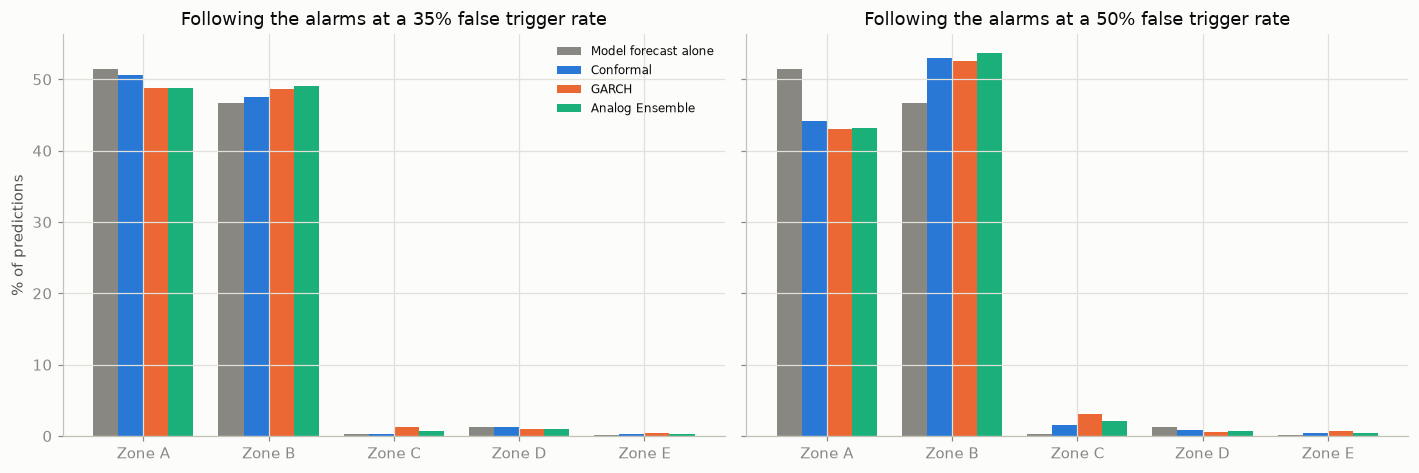

In [11]:
base = clarke_zone_percentages(actual_all, pred_all)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
for ax, t in zip(axes, TARGETS):
    x = np.arange(len(zones))
    w = 0.8 / (len(METHODS) + 1)
    ax.bar(x - 1.5 * w, [base[z] for z in zones], w, color=plotting.INK_MUTED, label="Model forecast alone")
    for i, method in enumerate(METHODS):
        pct = clarke_zone_percentages(actual_all, swapped[(method, t)])
        ax.bar(x + (i - 0.5) * w, [pct[z] for z in zones], w, color=METHOD_COLOR[method], label=method)
    ax.set_xticks(x)
    ax.set_xticklabels([f"Zone {z}" for z in zones])
    ax.set_title(f"Following the alarms at a {int(t * 100)}% false trigger rate")
axes[0].set_ylabel("% of predictions")
axes[0].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

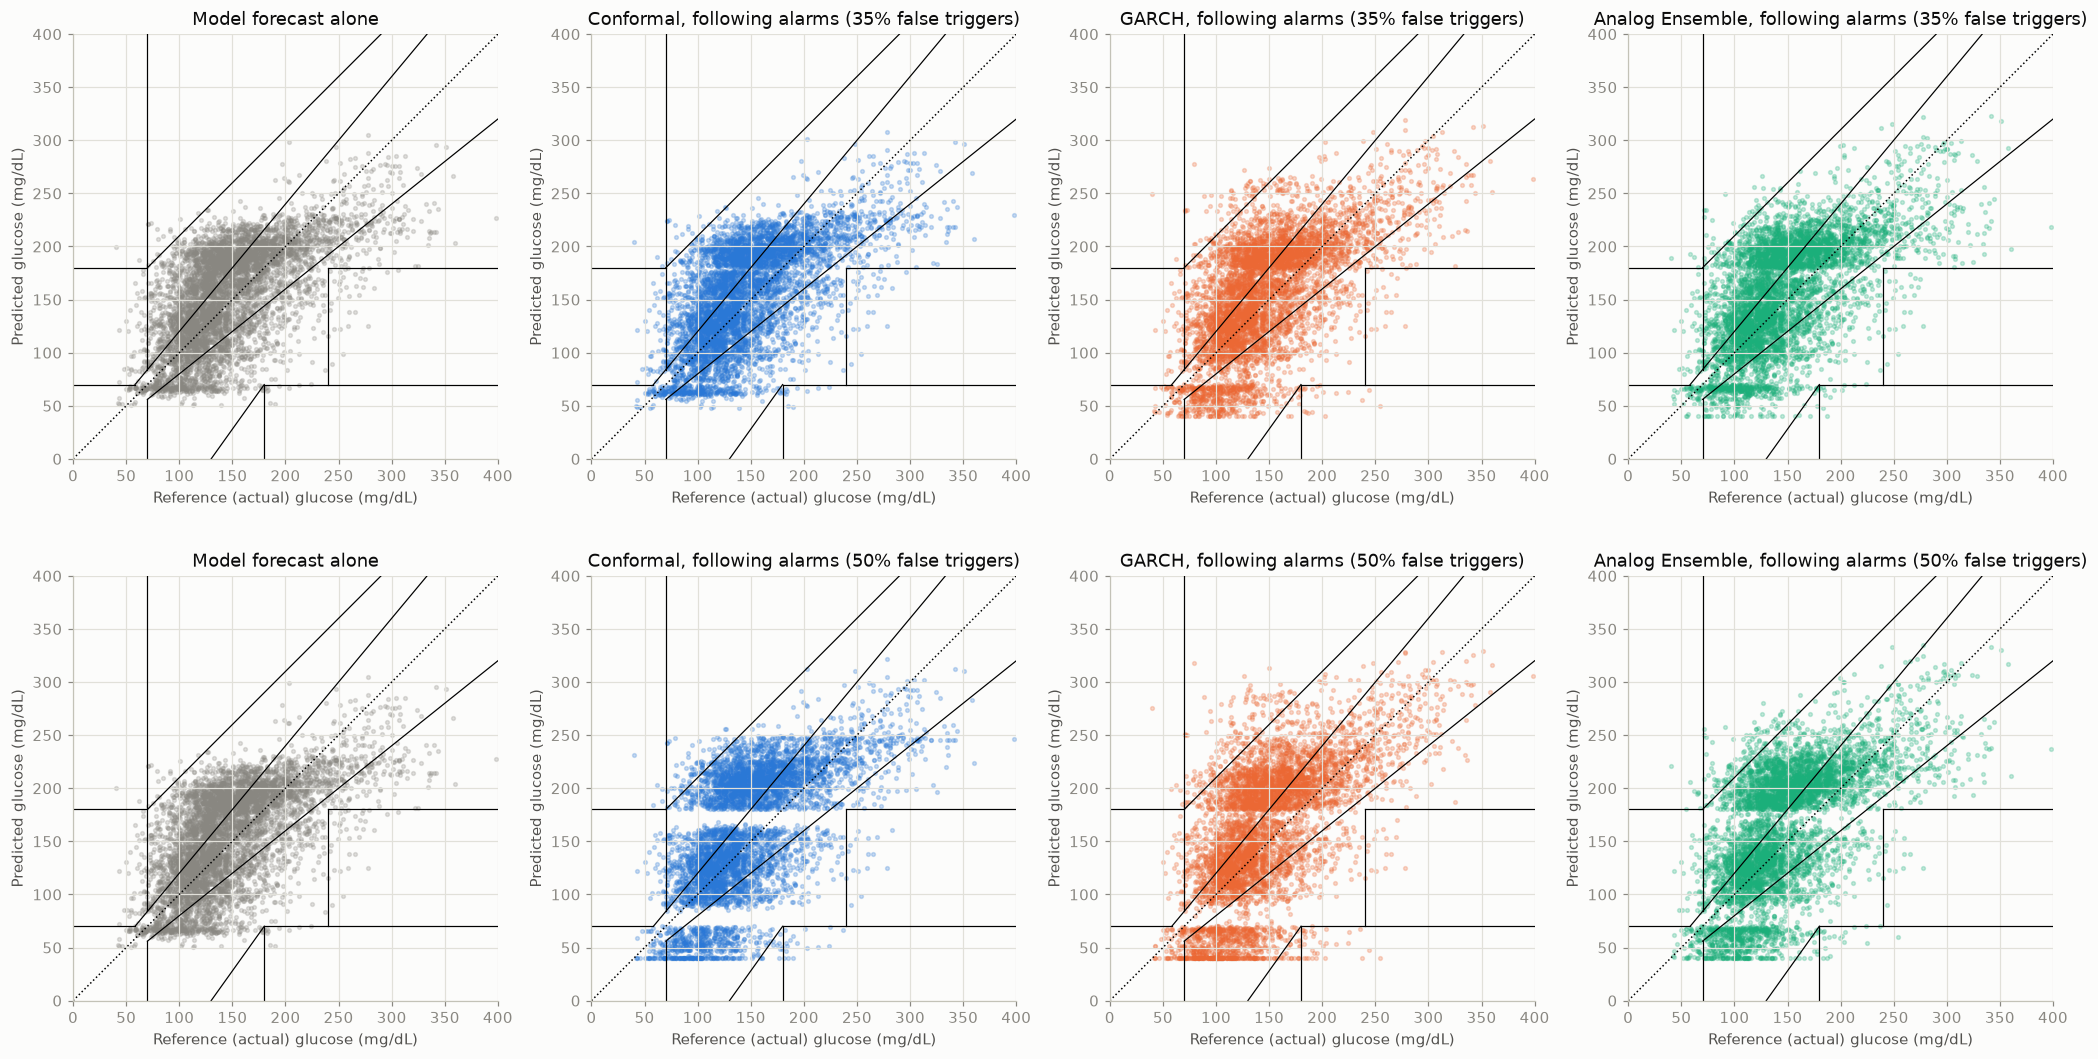

In [12]:
rng = np.random.default_rng(0)
sample = rng.choice(len(actual_all), 6000, replace=False)
fig, axes = plt.subplots(2, 4, figsize=(19, 10))
for r, t in enumerate(TARGETS):
    draw_clarke_grid(axes[r, 0], actual_all[sample], pred_all[sample], plotting.INK_MUTED)
    axes[r, 0].set_title("Model forecast alone")
    for c, method in enumerate(METHODS, start=1):
        draw_clarke_grid(axes[r, c], actual_all[sample], swapped[(method, t)][sample], METHOD_COLOR[method])
        axes[r, c].set_title(f"{method}, following alarms ({int(t * 100)}% false triggers)")
fig.tight_layout()
plt.show()

The false trigger rate above is pooled across all 25 patients. Below is the same thing for each patient separately, at the band size that gives the pooled 35% and 50% rates. If the dots are tightly grouped, one band size works for everyone. If they spread out, some patients would be getting far more false alarms than the pooled number suggests.

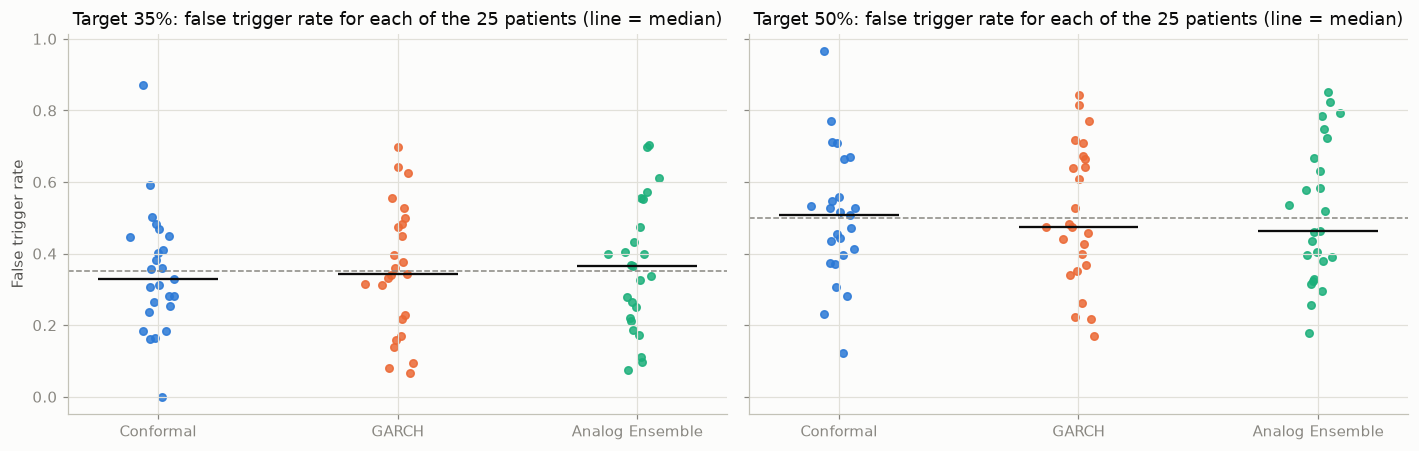

lowest patient  median patient  \
false trigger target method                                            
35%                  Conformal                 0.000           0.328   
                     GARCH                     0.068           0.342   
                     Analog Ensemble           0.075           0.364   
50%                  Conformal                 0.123           0.508   
                     GARCH                     0.171           0.475   
                     Analog Ensemble           0.179           0.463   

                                      highest patient  patients above 50%  
false trigger target method                                                
35%                  Conformal                  0.870                   3  
                     GARCH                      0.697                   5  
                     Analog Ensemble            0.703                   6  
50%                  Conformal                  0.965                  13  
                     GARCH                      0.842                  11  
                     Analog Ensemble            0.852                  12

In [13]:
per_patient_rows = []
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for ax, t in zip(axes, TARGETS):
    for i, method in enumerate(METHODS):
        vals = []
        for sid in subject_ids:
            lo, hi = engines[sid].bands(method, matched[(method, t)])
            vals.append(unc.trigger_metrics(actuals[sid], lo, hi)["false_trigger_rate"])
        per_patient_rows.append({"false trigger target": f"{int(t * 100)}%", "method": method, "lowest patient": min(vals),
                                 "median patient": float(np.median(vals)), "highest patient": max(vals),
                                 "patients above 50%": int(sum(v > 0.5 for v in vals))})
        jitter = np.random.default_rng(i).normal(0, 0.05, len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals, color=METHOD_COLOR[method], s=24, alpha=0.85)
        ax.hlines(np.median(vals), i - 0.25, i + 0.25, color=plotting.INK_PRIMARY, linewidth=1.5)
    ax.axhline(t, linestyle="--", color=plotting.INK_MUTED, linewidth=1)
    ax.set_xticks(range(len(METHODS)))
    ax.set_xticklabels(METHODS)
    ax.set_title(f"Target {int(t * 100)}%: false trigger rate for each of the 25 patients (line = median)")
axes[0].set_ylabel("False trigger rate")
fig.tight_layout()
plt.show()
display(pd.DataFrame(per_patient_rows).set_index(["false trigger target", "method"]).round(3))

## 7. What this shows

All numbers pool the 25 patients' test periods (about 60,000 predictions: 963 real lows, 11,525 real highs, 47,521 safe readings). Nothing was fitted on the test period. This is one model (the fixed-weight CNN-LSTM) on one dataset (AZT1D), so it is a first look, not a final answer.

**Under the rule you asked about, ordinary bands would cry wolf almost constantly.** Triggering whenever either edge of an 80% band leaves the 70 to 180 zone falsely triggers on 86% of safe readings for conformal, 80% for GARCH, and 68% for the analog ensemble. At 95% it is 100%, 94%, and 93%. Roughly three out of four alarms would be false. The reason is simple: the safe zone is only 110 mg/dL wide and these bands are about that wide (or wider) on their own, so they leave the zone whether or not anything dangerous is happening. Danger is caught almost every time (92% to 100%), but that is easy when nearly everything triggers.

**There is a floor under the false trigger rate that no band can get below.** The raw model forecast, used as an alarm with no band at all, already falsely triggers on 32% of safe readings (and catches 72% of real danger, including only 45% of real lows). A band only ever adds room on either side of its center, so conformal, which is centered on the raw forecast, cannot do better than 32%. GARCH and the analog ensemble also shift their center to correct for the model's usual bias, which lowers their floors to 22% and 14%, but at the cost of catching less danger at that floor (61% and 53%). This is why the methods are compared at 35% and 50% false triggers rather than 10% or 25%: lower rates are not reachable for all three.

**The false triggers come mostly from the top edge.** At a 35% false trigger rate, 26% to 30% of safe readings falsely trigger through the top edge (above 180) and only 6% to 9% through the bottom edge (below 70). The model tends to forecast high, so its forecast and its top edge sit above 180 while real glucose is still in range. Subject 1 shows it: the forecast hovers near 190 for hours while real glucose is 150 to 170, and the alarm fires the whole time.

**At the same false trigger rate, the three methods are close to indistinguishable.** At 35% false triggers they catch 74.0% (conformal), 75.5% (GARCH), and 76.5% (analog) of real danger. At 50% it is 84.2%, 84.6%, and 84.8%. The curves in section 4 lie almost on top of each other. The differences that exist are small and go different ways: conformal catches the most real lows at 35% (49% against 46% and 38%), and the analog ensemble catches the most real highs (80% against 78% and 76%). No method is a clear winner.

**A band adds little over just using the forecast.** The raw forecast catches 72.2% of danger at 32% false triggers. Conformal at 35% catches 74.0%. So about 3 extra points of false triggers buys about 2 extra points of danger caught. Getting to roughly 85% of danger caught costs a 50% false trigger rate, meaning half of all safe readings would set off the alarm.

**Following the alarms on the Clarke Error Grid.** Replacing the forecast with the edge that crossed the line makes the dangerous miss (zone D) rarer, and it costs accuracy elsewhere. The raw forecast has 1.33% in zone D. At a 35% false trigger rate this falls to 1.24% (conformal), 0.95% (GARCH), and 1.02% (analog), a small gain. At 50% it falls to 0.81%, 0.62%, and 0.70%, roughly a 40% to 55% cut. The price is zone C (a prediction far enough above the truth to prompt an unneeded correction), which rises from 0.25% to 1.6% to 3.1% at 50%, and zone A (clinically fine), which drops from 51.5% to about 43% to 44%. The worst-case zone E also rises, from 0.21% to 0.41% to 0.66%. Between 43% and 57% of predictions get replaced by an edge, depending on the setting.

**The same band size gives very different false trigger rates for different patients.** At the band size that gives 35% overall, individual patients range from about 0% to 87% (conformal), 7% to 70% (GARCH), and 8% to 70% (analog), and 3 to 6 of the 25 patients are above 50%. At the 50% setting, 11 to 13 of the 25 patients are above 50% and the worst patient is at 84% to 97%. A single band size for everyone would leave some patients with an alarm that fires nearly all the time.

**Caveats.** The bands are calibrated on each patient's validation period and judged on a later test period, so any drift shows up as missed danger or extra false triggers. Consecutive predictions overlap heavily, which means conformal's usual guarantee does not strictly apply. The analog settings (50 analogs, spacing, time-of-day weight) were not tuned. Danger here includes highs over 180, which are less urgent than lows; a stricter definition (lows only, or under 54) would change the numbers.

**Next step this points to.** Because the false triggers come mostly from the top edge and the real emergency is the low side, the obvious follow-up is to size the two edges separately: a wide bottom edge to catch lows, and a narrow (or no) top edge so the model's habit of forecasting high stops setting off the alarm.

## Appendix: the earlier coverage and Clarke material

These sections come from the first version of this notebook, which asked a different question: how well do the bands contain the real glucose, and how do the band edges look when graded as predictions. They use the ordinary 80% and 95% bands.

**Coverage** is the share of test readings where real glucose landed inside the band. A 95% band should contain the truth 95% of the time. The table splits it by what real glucose actually was. "Interval score" combines band width and misses into one number (lower is better).

In [14]:
LEVELS = (0.8, 0.95)
pooled = {(m, lv): (actual_all, *pooled_bands(m, lv)) for m in METHODS for lv in LEVELS}
rows = []
for (method, level), (actual, lo, hi) in pooled.items():
    m = unc.interval_metrics(actual, lo, hi, level)
    per_patient = [unc.interval_metrics(actuals[s], *engines[s].bands(method, level), level)["coverage"] for s in subject_ids]
    rows.append({"method": method, "band": f"{int(level * 100)}%", "coverage": m["coverage"],
                 "coverage_when_real_low": m["coverage_hypo"], "coverage_when_real_normal": m["coverage_normal"],
                 "coverage_when_real_high": m["coverage_hyper"], "mean_width": m["width"], "interval_score": m["interval_score"],
                 "worst_patient_coverage": min(per_patient), "best_patient_coverage": max(per_patient)})
pd.DataFrame(rows).set_index(["band", "method"]).sort_index().round(3)

coverage  coverage_when_real_low  \
band method                                              
80%  Analog Ensemble     0.739                   0.521   
     Conformal           0.776                   0.714   
     GARCH               0.784                   0.746   
95%  Analog Ensemble     0.896                   0.725   
     Conformal           0.942                   0.855   
     GARCH               0.919                   0.892   

                      coverage_when_real_normal  coverage_when_real_high  \
band method                                                                
80%  Analog Ensemble                      0.766                    0.649   
     Conformal                            0.783                    0.752   
     GARCH                                0.791                    0.759   
95%  Analog Ensemble                      0.917                    0.824   
     Conformal                            0.956                    0.891   
     GARCH                                0.929                    0.882   

                      mean_width  interval_score  worst_patient_coverage  \
band method                                                                
80%  Analog Ensemble      81.240         134.913                   0.618   
     Conformal            97.434         144.012                   0.681   
     GARCH               100.821         145.898                   0.685   
95%  Analog Ensemble     123.203         200.825                   0.781   
     Conformal           149.182         194.892                   0.880   
     GARCH               147.716         213.646                   0.857   

                      best_patient_coverage  
band method                                  
80%  Analog Ensemble                  0.858  
     Conformal                        0.895  
     GARCH                            0.857  
95%  Analog Ensemble                  0.953  
     Conformal                        0.975  
     GARCH                            0.967

**Band edges graded as predictions on the Clarke grid.** Each band's bottom edge and top edge is treated as if it were a prediction against the real glucose. A wide band pushes its edges away from the truth by design, so many edge predictions land outside zone A. Bottom edges below 40 mg/dL are clipped to 40, the sensor floor.

In [15]:
zone_rows = [{"what is graded": "Point forecast (no band)", "band": "-", **clarke_zone_percentages(actual_all, pred_all)}]
for (method, level), (actual, lo, hi) in pooled.items():
    z = unc.band_edge_zones(actual, lo, hi)
    for edge in ("lower", "upper"):
        zone_rows.append({"what is graded": f"{method}, {edge} edge", "band": f"{int(level * 100)}%", **z[edge]})
pd.DataFrame(zone_rows).set_index(["what is graded", "band"]).round(2)

,,A,B,C,D,E
what is graded,band,,,,,
Point forecast (no band),-,51.50,46.70,0.25,1.33,0.21
"Conformal, lower edge",80%,35.55,59.50,0.68,3.42,0.85
"Conformal, upper edge",80%,22.33,66.63,9.21,1.49,0.33
"Conformal, lower edge",95%,13.90,77.92,1.80,4.09,2.28
"Conformal, upper edge",95%,10.43,61.31,26.51,1.17,0.58
"GARCH, lower edge",80%,30.65,62.50,1.25,3.14,2.46
"GARCH, upper edge",80%,28.90,59.20,10.06,1.34,0.49
"GARCH, lower edge",95%,14.71,73.75,3.09,2.60,5.85
"GARCH, upper edge",95%,14.90,59.27,24.04,0.97,0.81


**Does a wider band warn about a forecast that is about to be clinically wrong?** Below, the point forecast is graded on the Clarke grid as usual and the average band width is compared across zones. The warning score is the chance that a randomly picked clinically bad forecast (zone C, D, or E) has a wider band than a randomly picked fine one (zone A or B): 0.5 means the width tells you nothing, 1.0 means it flags every bad forecast. Conformal has a constant width, so it should sit near 0.5 (it drifts slightly because bands are clipped at the sensor limits).

In [16]:
width_rows, auc_rows = [], []
for method in METHODS:
    for level in LEVELS:
        actual, lo, hi = pooled[(method, level)]
        width_rows.append({"method": method, "band": f"{int(level * 100)}%", **unc.width_by_point_zone(actual_all, pred_all, hi - lo)})
        auc_rows.append({"method": method, "band": f"{int(level * 100)}%", "warning score": unc.width_warning_auc(actual_all, pred_all, hi - lo)})
print("Mean band width (mg/dL) by Clarke zone of the point forecast:")
display(pd.DataFrame(width_rows).set_index(["band", "method"]).sort_index().round(1))
print("Warning score (0.5 = no information, 1.0 = perfect):")
display(pd.DataFrame(auc_rows).set_index(["band", "method"]).sort_index().round(3))

Mean band width (mg/dL) by Clarke zone of the point forecast:


A      B      C      D      E
band method                                            
80%  Analog Ensemble   79.2   83.2   92.6   85.7   86.7
     Conformal         96.8   98.0  101.2  100.1   88.8
     GARCH             98.2  103.1  112.9  118.1  110.9
95%  Analog Ensemble  121.9  124.5  137.4  128.1  125.4
     Conformal        150.0  148.4  158.2  148.3  130.0
     GARCH            144.5  150.6  164.6  165.0  159.1

Warning score (0.5 = no information, 1.0 = perfect):


warning score
band method                        
80%  Analog Ensemble          0.579
     Conformal                0.514
     GARCH                    0.581
95%  Analog Ensemble          0.566
     Conformal                0.467
     GARCH                    0.564